# Phân tích các yếu tố ảnh hưởng đến kết quả học tập của học sinh -  *Students Performance in Exams* (Kaggle)
## Lê Hải Phúc - 23730116

Dataset: **Students Performance in Exams**  
Nguồn: Kaggle – https://www.kaggle.com/datasets/spscientist/students-performance-in-exams/

Truy cập Notebook trên Google Colab: https://colab.research.google.com/drive/1llNU7SirWzPGqdK_sEn2ncBrP6cpLYE8?usp=sharing

In [ ]:
!pip -q install numpy pandas matplotlib scipy statsmodels patsy
%matplotlib inline

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

from patsy import dmatrices
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import jarque_bera


In [ ]:
# NẠP DỮ LIỆU TỪ KAGGLE thông qua kagglehub

!pip -q install kagglehub[pandas-datasets]
import warnings
import kagglehub
from kagglehub import KaggleDatasetAdapter

DATASET_ID = "spscientist/students-performance-in-exams"
file_path = "StudentsPerformance.csv"

with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=DeprecationWarning)
    raw_df = kagglehub.load_dataset(
        KaggleDatasetAdapter.PANDAS,
        DATASET_ID,
        file_path,
    )

print("First 5 records:")
display(raw_df.head())


Using Colab cache for faster access to the 'students-performance-in-exams' dataset.
First 5 records:


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


## 0) Cấu hình notebook


In [ ]:

# Thứ tự học vấn
THU_TU_HOC_VAN = [
    "some high school",
    "high school",
    "some college",
    "associate's degree",
    "bachelor's degree",
    "master's degree",
]

# Cấu hình hiển thị bảng cho dễ nhìn
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)


## 1) Manifest


In [ ]:
from IPython.display import display, Markdown

def tieu_de(text: str, level: int = 3) -> None:
    """Hiển thị tiêu đề dạng Markdown trong notebook."""
    level = int(level)
    level = 1 if level < 1 else (6 if level > 6 else level)
    display(Markdown(f"{'#'*level} {text}"))

def hien_thi_bang(title: str, df: pd.DataFrame) -> None:
    tieu_de(title, level=4)
    display(df)


## 2) Nạp và chuẩn hóa dữ liệu


In [ ]:
def tai_va_chuan_hoa_du_lieu(du_lieu: "str | pd.DataFrame") -> pd.DataFrame:
    """Nạp dữ liệu và chuẩn hóa cột/nhãn.

    - Nếu `du_lieu` là đường dẫn CSV (str) -> đọc bằng pandas.
    - Nếu `du_lieu` là DataFrame -> dùng trực tiếp (copy) để chuẩn hóa.
    """
    if isinstance(du_lieu, pd.DataFrame):
        df = du_lieu.copy()
    else:
        df = pd.read_csv(du_lieu)
    if {"gender", "math score", "reading score", "writing score"}.issubset(df.columns):
        df = df.rename(columns={
            "gender": "gioi_tinh",
            "race/ethnicity": "nhom_dan_toc",
            "parental level of education": "hoc_van_phu_huynh",
            "lunch": "bua_trua",
            "test preparation course": "khoa_on_luyen",
            "math score": "diem_toan",
            "reading score": "diem_doc",
            "writing score": "diem_viet",
        })

        # Chuẩn hóa nhãn giới tính: female->F, male->M
        df["gioi_tinh"] = df["gioi_tinh"].astype(str).str.strip().str.lower().map({
            "female": "F",
            "male": "M"
        }).fillna(df["gioi_tinh"])

    # Trường hợp 2: Một số bản mirror dùng điểm 0–1 (tỷ lệ)
    elif {"math_percentage", "reading_percentage", "writing_percentage"}.issubset(df.columns):
        for cot in ["math_percentage", "reading_percentage", "writing_percentage"]:
            df[cot] = df[cot] * 100.0
        df = df.rename(columns={
            "gender": "gioi_tinh",
            "race_ethnicity": "nhom_dan_toc",
            "parental_level_of_education": "hoc_van_phu_huynh",
            "lunch": "bua_trua",
            "test_preparation_course": "khoa_on_luyen",
            "math_percentage": "diem_toan",
            "reading_percentage": "diem_doc",
            "writing_percentage": "diem_viet",
        })
        df["gioi_tinh"] = df["gioi_tinh"].astype(str).str.strip().str.lower().map({
            "female": "F",
            "male": "M",
            "f": "F",
            "m": "M",
        }).fillna(df["gioi_tinh"])
    else:
        raise ValueError(
            "Không nhận diện được định dạng cột. Hãy dùng file Kaggle chuẩn "
            "có các cột: gender, math score, reading score, writing score."
        )

    # Ép kiểu điểm
    for cot in ["diem_toan", "diem_doc", "diem_viet"]:
        df[cot] = pd.to_numeric(df[cot], errors="coerce")

    # Tạo điểm trung bình
    df["diem_trung_binh"] = (df["diem_toan"] + df["diem_doc"] + df["diem_viet"]) / 3.0

    # Loại dòng thiếu điểm
    truoc = len(df)
    df = df.dropna(subset=["diem_toan", "diem_doc", "diem_viet"])
    sau = len(df)
    if sau < truoc:
        print(f"[Lưu ý] Đã loại {truoc - sau} dòng do thiếu dữ liệu điểm.")

    # Chuẩn hóa chuỗi (bỏ khoảng trắng thừa)
    for cot in ["nhom_dan_toc", "bua_trua", "khoa_on_luyen"]:
        if cot in df.columns:
            df[cot] = df[cot].astype("string").str.strip()

    # Chuẩn hóa học vấn theo thứ tự
    if "hoc_van_phu_huynh" in df.columns:
        s = df["hoc_van_phu_huynh"].astype("string").str.strip()
        s = s.str.lower()
        df["hoc_van_phu_huynh"] = pd.Categorical(s, categories=THU_TU_HOC_VAN, ordered=True)

    return df


## 3) Thống kê mô tả + bảng tổng hợp


In [ ]:
def thong_ke_mo_ta(df: pd.DataFrame) -> dict:
    """Tính & hiển thị các bảng thống kê mô tả và bảng tổng hợp theo nhóm.

    Trả về dict các DataFrame để bạn có thể tái sử dụng.
    """
    bang_kq = {}

    # Bảng 1: thống kê mô tả
    cols = ["diem_toan", "diem_doc", "diem_viet", "diem_trung_binh"]
    mo_ta = df[cols].describe()
    mo_ta.loc["Trung vị"] = df[cols].median()
    mo_ta.loc["Phương sai"] = df[cols].var(ddof=1)

    mo_ta = mo_ta.rename(index={
        "count": "n",
        "mean": "Trung bình",
        "std": "Độ lệch chuẩn",
        "min": "Nhỏ nhất",
        "25%": "Q1 (25%)",
        "50%": "Q2 (50%)",
        "75%": "Q3 (75%)",
        "max": "Lớn nhất",
    })
    bang_kq["bang_1_thong_ke_mo_ta"] = mo_ta
    hien_thi_bang("Bảng 1 — Thống kê mô tả", mo_ta)

    # Bảng tổng hợp theo nhóm (count/mean/std)
    def tom_tat_theo_nhom(cot_nhom: str) -> pd.DataFrame | None:
        if cot_nhom not in df.columns:
            return None
        bang = (
            df.groupby(cot_nhom, dropna=True, observed=False)["diem_trung_binh"]
              .agg(["count", "mean", "std"])
              .reset_index()
        )
        return bang

    mapping = [
        ("gioi_tinh", "Bảng 2A — Điểm TB theo giới tính"),
        ("bua_trua", "Bảng 2B — Điểm TB theo bữa trưa"),
        ("khoa_on_luyen", "Bảng 2C — Điểm TB theo ôn luyện"),
        ("hoc_van_phu_huynh", "Bảng 3 — Điểm TB theo học vấn phụ huynh"),
    ]
    for cot, title in mapping:
        bang = tom_tat_theo_nhom(cot)
        if bang is None:
            continue
        bang_kq[f"tom_tat_{cot}"] = bang
        hien_thi_bang(title, bang)

    return bang_kq


## 4) Trực quan hóa (Hình 1 → 10)


In [ ]:
def _lay_ds_nhom_theo_thu_tu(df: pd.DataFrame, cot_nhom: str):
    series = df[cot_nhom]
    if isinstance(series.dtype, pd.CategoricalDtype):
        return [c for c in series.cat.categories if c in set(series.dropna().astype(str).tolist())] or list(series.dropna().unique())
    return list(series.dropna().unique())

def ve_histogram(df: pd.DataFrame, cot: str, tieu_de_hinh: str) -> None:
    """
    Histogram dùng để kiểm tra phân phối điểm (lệch trái/phải, đa đỉnh),
    phát hiện outlier và đánh giá sơ bộ giả định gần chuẩn trước khi kiểm định.
    """
    plt.figure()
    plt.hist(df[cot].dropna(), bins=30)
    plt.xlabel(cot.replace("_", " "))
    plt.ylabel("Tần suất")
    plt.title(tieu_de_hinh)
    plt.tight_layout()
    plt.show()

def ve_boxplot_diem_tb(df: pd.DataFrame, cot_nhom: str, nhan_truc_x: str) -> None:
    """Boxplot điểm trung bình theo 1 biến phân nhóm."""
    if cot_nhom not in df.columns:
        return
    ds_nhom = _lay_ds_nhom_theo_thu_tu(df, cot_nhom)
    du_lieu = [df.loc[df[cot_nhom] == g, "diem_trung_binh"].dropna().to_numpy() for g in ds_nhom]

    plt.figure()
    import inspect
    params = inspect.signature(plt.boxplot).parameters
    if 'tick_labels' in params:
        plt.boxplot(du_lieu, tick_labels=[str(g) for g in ds_nhom], showmeans=True)
    else:
        plt.boxplot(du_lieu, labels=[str(g) for g in ds_nhom], showmeans=True)
    plt.xlabel(nhan_truc_x)
    plt.ylabel("Điểm trung bình")
    plt.title(f"Điểm trung bình theo {nhan_truc_x}")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.show()

def ve_bar_hoc_van(df: pd.DataFrame) -> None:
    """Bar chart điểm trung bình theo học vấn phụ huynh (kèm SD)."""
    if "hoc_van_phu_huynh" not in df.columns:
        return
    bang = (
        df.groupby("hoc_van_phu_huynh", dropna=True, observed=False)["diem_trung_binh"]
          .agg(["mean", "std", "count"])
          .reset_index()
    )
    if isinstance(df["hoc_van_phu_huynh"].dtype, pd.CategoricalDtype):
        bang = bang.sort_values("hoc_van_phu_huynh")

    x = np.arange(len(bang))
    y = bang["mean"].to_numpy()
    yerr = bang["std"].to_numpy()

    plt.figure()
    plt.bar(x, y)
    plt.errorbar(x, y, yerr=yerr, fmt="none", capsize=3)
    plt.xticks(x, bang["hoc_van_phu_huynh"].astype(str), rotation=25, ha="right")
    plt.ylabel("Điểm trung bình")
    plt.title("Điểm trung bình theo học vấn phụ huynh")
    plt.tight_layout()
    plt.show()

def ve_heatmap_tuong_quan(df: pd.DataFrame) -> None:
    """Heatmap tương quan Pearson giữa Toán/Đọc/Viết (có số)."""
    mat = df[["diem_toan", "diem_doc", "diem_viet"]].corr(method="pearson")
    plt.figure()
    plt.imshow(mat, aspect="auto")
    plt.colorbar()
    labels = ["Toán", "Đọc", "Viết"]
    plt.xticks(range(3), labels)
    plt.yticks(range(3), labels)
    plt.title("Tương quan Pearson giữa các môn")
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            plt.text(j, i, f"{mat.iloc[i, j]:.3f}", ha="center", va="center")
    plt.tight_layout()
    plt.show()

def ve_scatter_toan_doc(df: pd.DataFrame) -> None:
    """Scatter Toán vs Đọc + đường hồi quy tuyến tính đơn giản."""
    x = df["diem_toan"].to_numpy()
    y = df["diem_doc"].to_numpy()

    plt.figure()
    plt.scatter(x, y)
    plt.xlabel("Điểm Toán")
    plt.ylabel("Điểm Đọc")
    plt.title("Scatter: Điểm Toán và Điểm Đọc")

    # Vẽ đường hồi quy
    try:
        a, b = np.polyfit(x, y, 1)
        xs = np.linspace(x.min(), x.max(), 100)
        ys = a * xs + b
        plt.plot(xs, ys)
    except Exception:
        pass

    plt.tight_layout()
    plt.show()


## 5) Kiểm định giả thuyết (Welch t-test) + effect size


In [ ]:
def cohen_d(a: np.ndarray, b: np.ndarray) -> float:
    """Cohen's d cho 2 nhóm độc lập."""
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    na, nb = len(a), len(b)
    if na < 2 or nb < 2:
        return np.nan
    va = np.var(a, ddof=1)
    vb = np.var(b, ddof=1)
    sp = np.sqrt(((na - 1) * va + (nb - 1) * vb) / (na + nb - 2))
    return (np.mean(a) - np.mean(b)) / sp if sp != 0 else np.nan

def welch_ci_chenh_lech(a: np.ndarray, b: np.ndarray, alpha: float = 0.05) -> tuple[float, float, float]:
    """Ước lượng khoảng tin cậy (CI) cho chênh lệch trung bình theo công thức Welch.

    Trả về: (chenh_tb, ci_thap, ci_cao)
    """
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    na, nb = len(a), len(b)
    if na < 2 or nb < 2:
        return (np.nan, np.nan, np.nan)

    mean_a, mean_b = float(np.mean(a)), float(np.mean(b))
    var_a, var_b = float(np.var(a, ddof=1)), float(np.var(b, ddof=1))

    chenh_tb = mean_a - mean_b
    se = np.sqrt(var_a/na + var_b/nb)

    # bậc tự do xấp xỉ theo Welch–Satterthwaite
    df_num = (var_a/na + var_b/nb)**2
    df_den = (var_a**2)/(na**2*(na-1)) + (var_b**2)/(nb**2*(nb-1))
    df_welch = df_num / df_den if df_den != 0 else (na + nb - 2)

    t_crit = stats.t.ppf(1 - alpha/2, df_welch)
    ci_thap = chenh_tb - t_crit * se
    ci_cao  = chenh_tb + t_crit * se
    return (float(chenh_tb), float(ci_thap), float(ci_cao))




def uoc_luong_ci_trung_binh(df: pd.DataFrame, cot: str = "diem_trung_binh", alpha: float = 0.05) -> pd.DataFrame:
    """Ước lượng CI cho trung bình của một biến điểm (mặc định: điểm trung bình)."""
    x = df[cot].dropna().astype(float)
    n = int(x.shape[0])
    mean = float(x.mean())
    sd = float(x.std(ddof=1))
    se = sd / np.sqrt(n)
    t_crit = stats.t.ppf(1 - alpha/2, n-1)
    ci_thap = mean - t_crit * se
    ci_cao  = mean + t_crit * se
    bang = pd.DataFrame([{
        "Bien": cot,
        "n": n,
        "Trung_binh": mean,
        "Do_lech_chuan": sd,
        "CI_thap": ci_thap,
        "CI_cao": ci_cao
    }])
    hien_thi_bang("Bảng bổ sung — Ước lượng CI 95% cho trung bình", bang)
    return bang


def welch_ttest_bang(df: pd.DataFrame) -> pd.DataFrame:
    """Welch t-test trên điểm trung bình cho một số cặp so sánh phổ biến.

    Bổ sung: ước lượng chênh lệch trung bình và khoảng tin cậy (CI) 95%.
    """
    ds_kq = []

    # 1) Giới tính
    if "gioi_tinh" in df.columns and df["gioi_tinh"].nunique() >= 2:
        a = df[df["gioi_tinh"] == "F"]["diem_trung_binh"].dropna()
        b = df[df["gioi_tinh"] == "M"]["diem_trung_binh"].dropna()
        t, p = stats.ttest_ind(a, b, equal_var=False, nan_policy="omit")
        chenh_tb, ci_thap, ci_cao = welch_ci_chenh_lech(a, b)
        ds_kq.append({
            "So_sanh": "Giới tính: Nữ (F) vs Nam (M)",
            "Chenh_TB": chenh_tb,
            "CI_thap": ci_thap,
            "CI_cao": ci_cao,
            "p_value": float(p),
            "Cohen_d": float(cohen_d(a, b)),
            "t_stat": float(t),
        })

    # 2) Bữa trưa
    if "bua_trua" in df.columns and df["bua_trua"].nunique() >= 2:
        a = df[df["bua_trua"] == "standard"]["diem_trung_binh"].dropna()
        b = df[df["bua_trua"] == "free/reduced"]["diem_trung_binh"].dropna()
        t, p = stats.ttest_ind(a, b, equal_var=False, nan_policy="omit")
        chenh_tb, ci_thap, ci_cao = welch_ci_chenh_lech(a, b)
        ds_kq.append({
            "So_sanh": "Bữa trưa: Standard vs Free/Reduced",
            "Chenh_TB": chenh_tb,
            "CI_thap": ci_thap,
            "CI_cao": ci_cao,
            "p_value": float(p),
            "Cohen_d": float(cohen_d(a, b)),
            "t_stat": float(t),
        })

    # 3) Ôn luyện
    if "khoa_on_luyen" in df.columns and df["khoa_on_luyen"].nunique() >= 2:
        a = df[df["khoa_on_luyen"] == "completed"]["diem_trung_binh"].dropna()
        b = df[df["khoa_on_luyen"] == "none"]["diem_trung_binh"].dropna()
        t, p = stats.ttest_ind(a, b, equal_var=False, nan_policy="omit")
        chenh_tb, ci_thap, ci_cao = welch_ci_chenh_lech(a, b)
        ds_kq.append({
            "So_sanh": "Ôn luyện: Completed vs None",
            "Chenh_TB": chenh_tb,
            "CI_thap": ci_thap,
            "CI_cao": ci_cao,
            "p_value": float(p),
            "Cohen_d": float(cohen_d(a, b)),
            "t_stat": float(t),
        })

    bang = pd.DataFrame(ds_kq)

    # Sắp xếp cột để đọc dễ hơn
    cot_thu_tu = ["So_sanh", "Chenh_TB", "CI_thap", "CI_cao", "p_value", "Cohen_d", "t_stat"]
    cot_thu_tu = [c for c in cot_thu_tu if c in bang.columns]
    bang = bang[cot_thu_tu]

    hien_thi_bang("Bảng 4 — Welch t-test + CI 95% (điểm trung bình)", bang)
    return bang



## 6) ANOVA + Tukey (Học vấn phụ huynh)


In [ ]:
def anova_va_tukey(df: pd.DataFrame) -> dict:
    """ANOVA theo học vấn phụ huynh + Kruskal-Wallis + Tukey HSD."""
    bang_kq = {}
    if "hoc_van_phu_huynh" not in df.columns:
        return bang_kq

    # ANOVA một yếu tố
    mo_hinh = smf.ols("diem_trung_binh ~ C(hoc_van_phu_huynh)", data=df).fit()
    bang_anova = sm.stats.anova_lm(mo_hinh, typ=2)
    bang_kq["anova"] = bang_anova
    hien_thi_bang("Bảng 5A — ANOVA (1 yếu tố: học vấn phụ huynh)", bang_anova)

    # Kruskal-Wallis (phi tham số) để kiểm tra bổ sung
    nhom = [g["diem_trung_binh"].values for _, g in df.groupby("hoc_van_phu_huynh", dropna=True, observed=False)]
    if len(nhom) >= 2:
        H, p_kw = stats.kruskal(*nhom)
        bang_kw = pd.DataFrame([{"H": float(H), "p_value": float(p_kw)}])
        bang_kq["kruskal_wallis"] = bang_kw
        hien_thi_bang("Bảng 5B — Kruskal-Wallis", bang_kw)

    # Tukey HSD (hậu kiểm)
    tukey = pairwise_tukeyhsd(endog=df["diem_trung_binh"], groups=df["hoc_van_phu_huynh"], alpha=0.05)
    bang_tukey = pd.DataFrame(data=tukey._results_table.data[1:], columns=tukey._results_table.data[0])
    bang_kq["tukey"] = bang_tukey
    hien_thi_bang("Bảng 6 — Tukey HSD (hậu kiểm)", bang_tukey)

    return bang_kq


## 7) Tương quan


In [ ]:
def tinh_tuong_quan(df: pd.DataFrame) -> pd.DataFrame:
    """Tính và hiển thị tương quan Pearson."""
    bang = df[["diem_toan", "diem_doc", "diem_viet"]].corr(method="pearson")
    hien_thi_bang("Bảng 7 — Tương quan Pearson (Toán/Đọc/Viết)", bang)
    return bang


## 8) Hồi quy đa biến + robust HC3 + VIF + chẩn đoán


In [ ]:
def hoi_quy_va_chan_doan(df: pd.DataFrame) -> dict:
    """Hồi quy OLS + robust HC3, kèm chẩn đoán & VIF. Hiển thị trực tiếp trong notebook."""
    bang_kq = {}

    # Xây công thức theo các biến có sẵn
    thanh_phan = [
        'C(gioi_tinh, Treatment(reference="F"))',
        'C(bua_trua, Treatment(reference="standard"))',
        'C(khoa_on_luyen, Treatment(reference="none"))',
        'C(hoc_van_phu_huynh, Treatment(reference="high school"))'
    ]
    if "nhom_dan_toc" in df.columns and df["nhom_dan_toc"].nunique(dropna=True) > 1:
        thanh_phan.append('C(nhom_dan_toc, Treatment(reference="group A"))')

    cong_thuc = "diem_trung_binh ~ " + " + ".join(thanh_phan)

    model = smf.ols(cong_thuc, data=df).fit()
    robust = model.get_robustcov_results(cov_type="HC3")

    # Bảng hệ số (robust)
    bang_hq = pd.DataFrame({
        "bien": robust.model.exog_names,
        "he_so": robust.params,
        "std_err": robust.bse,
        "t_stat": robust.tvalues,
        "p_value": robust.pvalues,
        "ci_lower": robust.conf_int()[:, 0],
        "ci_upper": robust.conf_int()[:, 1],
    })
    bang_kq["he_so_robust"] = bang_hq
    hien_thi_bang("Bảng 8 — Hệ số hồi quy (Robust HC3)", bang_hq)

    # VIF (đa cộng tuyến) – tính trên ma trận thiết kế
    try:
        _, X = dmatrices(cong_thuc, data=df, return_type="dataframe")
        ds_vif = []
        for i, col in enumerate(X.columns):
            if col == "Intercept":
                continue
            vif = variance_inflation_factor(X.values, i)
            ds_vif.append({"bien": col, "VIF": float(vif)})
        bang_vif = pd.DataFrame(ds_vif).sort_values("VIF", ascending=False).reset_index(drop=True)
        bang_kq["vif"] = bang_vif
        hien_thi_bang("Bảng VIF — Kiểm tra đa cộng tuyến", bang_vif)
    except Exception as e:
        print("[Cảnh báo] Không tính được VIF:", e)

    # Chẩn đoán cơ bản
    jb_stat, jb_p, skew, kurt = jarque_bera(model.resid)
    try:
        bp_stat, bp_p, _, _ = het_breuschpagan(model.resid, model.model.exog)
    except Exception:
        bp_stat, bp_p = np.nan, np.nan

    bang_diag = pd.DataFrame([{
        "n": int(model.nobs),
        "R2": float(model.rsquared),
        "Adj_R2": float(model.rsquared_adj),
        "JB_stat": float(jb_stat),
        "JB_p": float(jb_p),
        "BP_stat": float(bp_stat) if np.isfinite(bp_stat) else np.nan,
        "BP_p": float(bp_p) if np.isfinite(bp_p) else np.nan,
    }])
    bang_kq["chan_doan"] = bang_diag
    hien_thi_bang("Chẩn đoán mô hình", bang_diag)

    tieu_de("Tóm tắt mô hình OLS", level=4)
    display(model.summary())

    tieu_de("Tóm tắt mô hình Robust HC3", level=4)
    display(robust.summary())

    # Một đoạn tóm tắt ngắn
    tieu_de("Tóm tắt nhanh (association, không khẳng định nhân quả)", level=4)
    print(f"Công thức: {cong_thuc}")
    print(f"R^2 = {model.rsquared:.4f} | Adj R^2 = {model.rsquared_adj:.4f}")
    print(f"Jarque-Bera p = {jb_p:.4g} | Breusch-Pagan p = {bp_p:.4g}")

    return bang_kq


## 9) Hiển thị tất cả kết quả

Số dòng dữ liệu: 1000


,gioi_tinh,nhom_dan_toc,hoc_van_phu_huynh,bua_trua,khoa_on_luyen,diem_toan,diem_doc,diem_viet,diem_trung_binh
0,F,group B,bachelor's degree,standard,none,72,72,74,72.666667
1,F,group C,some college,standard,completed,69,90,88,82.333333
2,F,group B,master's degree,standard,none,90,95,93,92.666667
3,M,group A,associate's degree,free/reduced,none,47,57,44,49.333333
4,M,group C,some college,standard,none,76,78,75,76.333333


#### Bảng 1 — Thống kê mô tả

,diem_toan,diem_doc,diem_viet,diem_trung_binh
n,1000.000000,1000.000000,1000.000000,1000.000000
Trung bình,66.089000,69.169000,68.054000,67.770667
Độ lệch chuẩn,15.163080,14.600192,15.195657,14.257326
Nhỏ nhất,0.000000,17.000000,10.000000,9.000000
Q1 (25%),57.000000,59.000000,57.750000,58.333333
Q2 (50%),66.000000,70.000000,69.000000,68.333333
Q3 (75%),77.000000,79.000000,79.000000,77.666667
Lớn nhất,100.000000,100.000000,100.000000,100.000000
Trung vị,66.000000,70.000000,69.000000,68.333333
Phương sai,229.918998,213.165605,230.907992,203.271344


#### Bảng 2A — Điểm TB theo giới tính

...

#### Bảng 2C — Điểm TB theo ôn luyện

,khoa_on_luyen,count,mean,std
0,completed,358,72.669460,13.036960
1,none,642,65.038941,14.186707


#### Bảng 3 — Điểm TB theo học vấn phụ huynh

,hoc_van_phu_huynh,count,mean,std
0,some high school,179,65.108007,14.984078
1,high school,196,63.096939,13.510583
2,some college,226,68.476401,13.710974
3,associate's degree,222,69.569069,13.670914
4,bachelor's degree,118,71.923729,13.946609
5,master's degree,59,73.598870,13.601017


### Hình 1–4: Histogram điểm

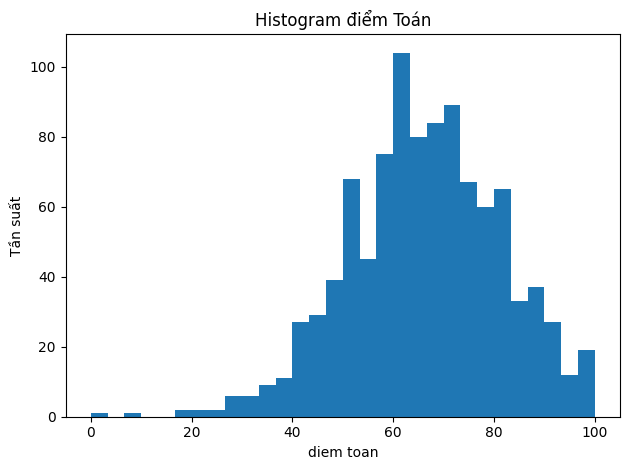

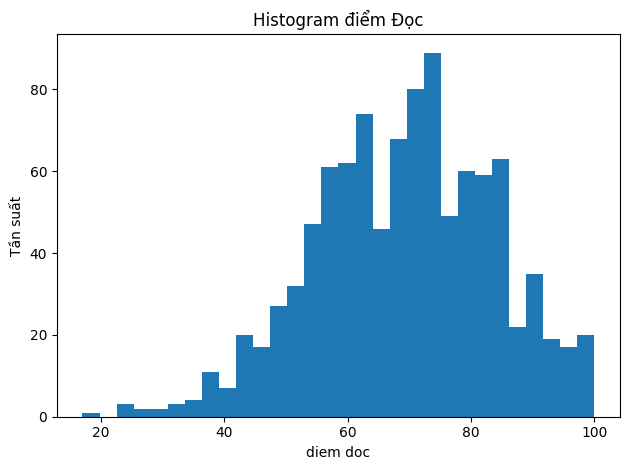

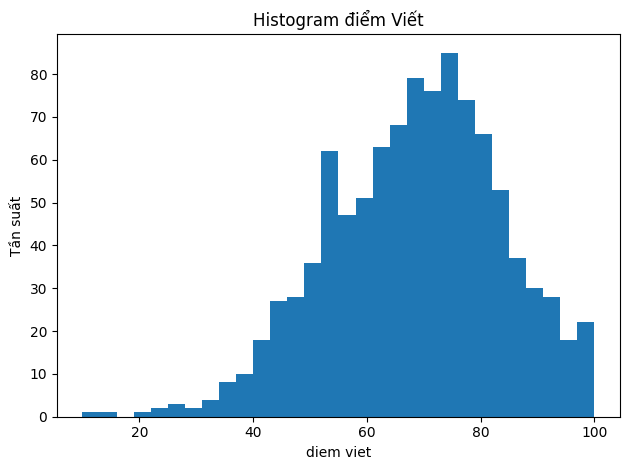

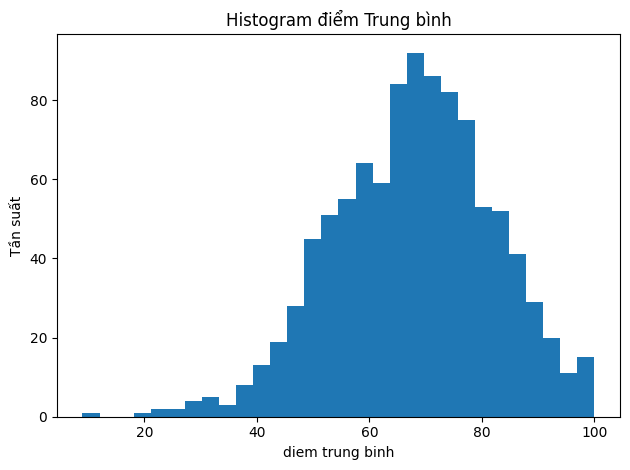

### Hình 5–7: Boxplot điểm trung bình theo nhóm

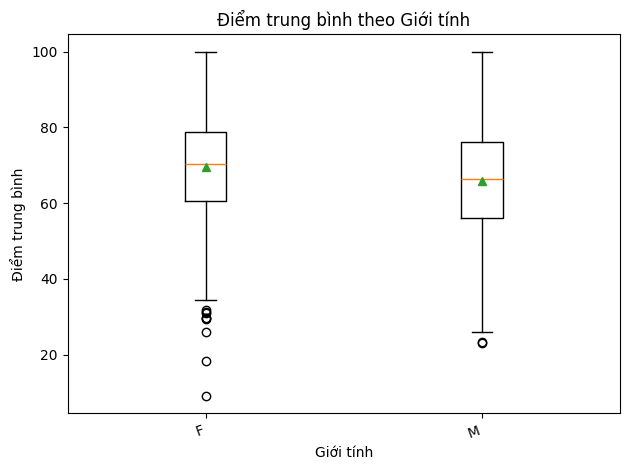

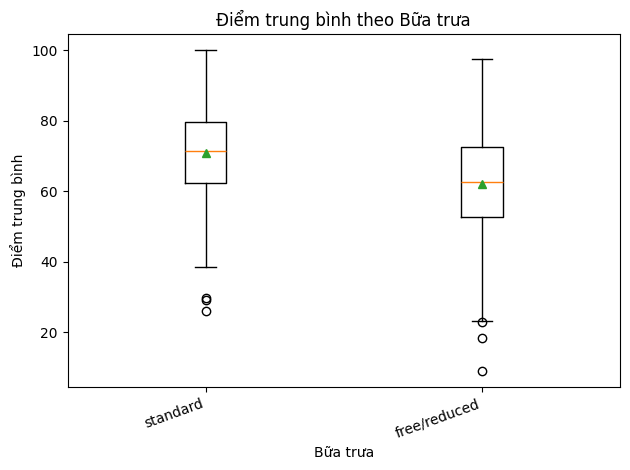

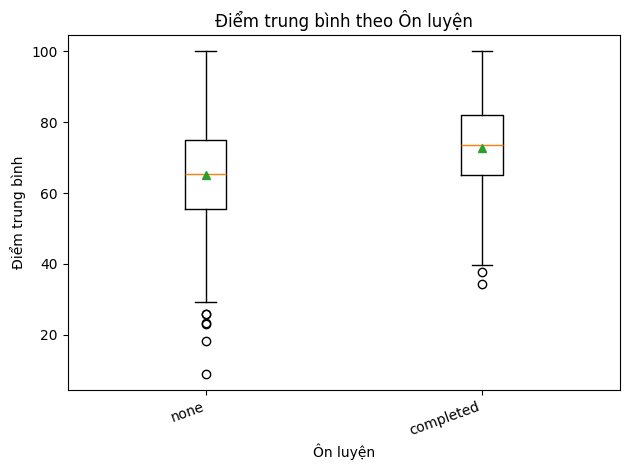

### Hình 8: Bar chart theo học vấn phụ huynh

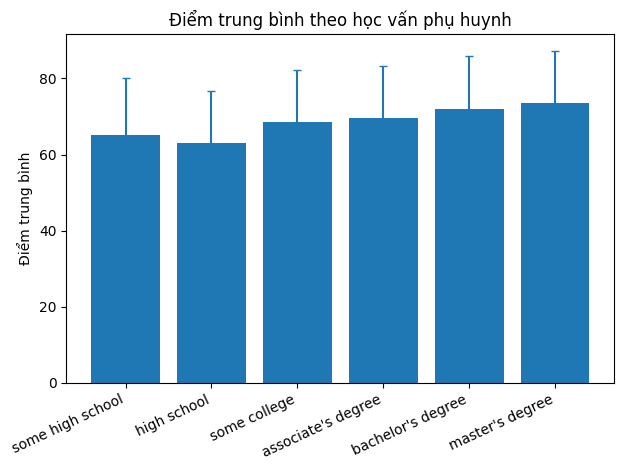

### Hình 9–10: Tương quan và Scatter

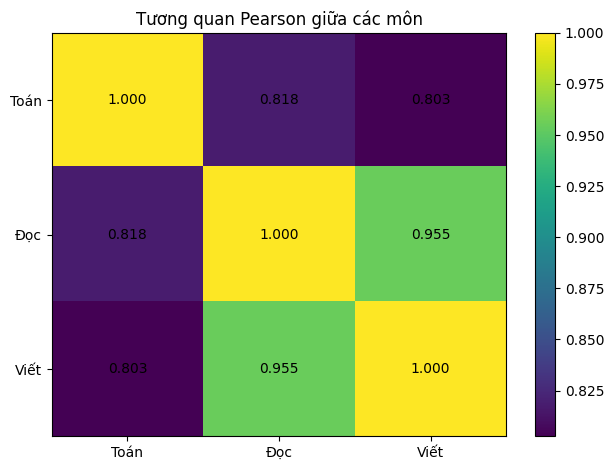

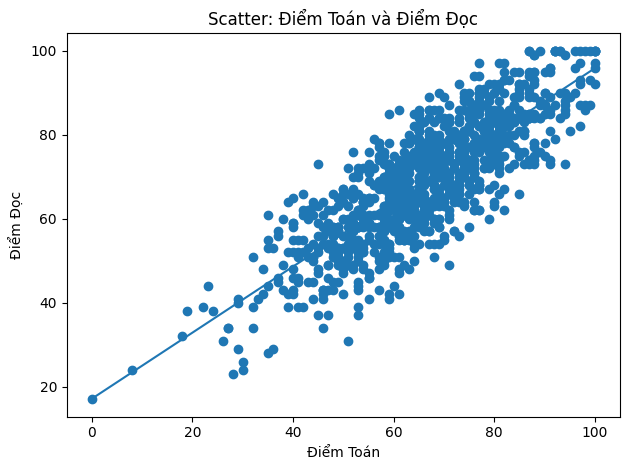

#### Bảng bổ sung — Ước lượng CI 95% cho trung bình

,Bien,n,Trung_binh,Do_lech_chuan,CI_thap,CI_cao
0,diem_trung_binh,1000,67.770667,14.257326,66.885933,68.655401


#### Bảng 4 — Welch t-test + CI 95% (điểm trung bình)

,So_sanh,Chenh_TB,CI_thap,CI_cao,p_value,Cohen_d,t_stat
0,Giới tính: Nữ (F) vs Nam (M),3.732015,1.979515,5.484516,3.186198e-05,0.263900,4.178886
1,Bữa trưa: Standard vs Free/Reduced,8.638148,6.818936,10.457360,1.582969e-19,0.632776,9.323207
2,Ôn luyện: Completed vs None,7.630519,5.887734,9.373305,4.426725e-17,0.553480,8.594538


#### Bảng 5A — ANOVA (1 yếu tố: học vấn phụ huynh)

...

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        diem_trung_binh   R-squared:                       0.242
Model:                            OLS   Adj. R-squared:                  0.233
Method:                 Least Squares   F-statistic:                     26.30
Date:                Thu, 08 Jan 2026   Prob (F-statistic):           7.55e-52
Time:                        09:23:03   Log-Likelihood:                -3937.0
No. Observations:                1000   AIC:                             7900.
Df Residuals:                     987   BIC:                             7964.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
==================================================================================================================================================
                                                                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                                         62.9048      1.678     37.478      0.000      59.611      66.199
C(gioi_tinh, Treatment(reference="F"))[T.M]                                       -3.7242      0.795     -4.682      0.000      -5.285      -2.163
C(bua_trua, Treatment(reference="standard"))[T.free/reduced]                      -8.7751      0.827    -10.605      0.000     -10.399      -7.151
C(khoa_on_luyen, Treatment(reference="none"))[T.completed]                         7.6386      0.830      9.201      0.000       6.009       9.268
C(hoc_van_phu_huynh, Treatment(reference="high school"))[T.some high school]       0.6325      1.300      0.486      0.627      -1.919       3.184
C(hoc_van_phu_huynh, Treatment(reference="high school"))[T.some college]           4.2450      1.225      3.466      0.001       1.842       6.648
C(hoc_van_phu_huynh, Treatment(reference="high school"))[T.associate's degree]     5.1725      1.230      4.206      0.000       2.759       7.586
C(hoc_van_phu_huynh, Treatment(reference="high school"))[T.bachelor's degree]      7.7081      1.460      5.278      0.000       4.842      10.574
C(hoc_van_phu_huynh, Treatment(reference="high school"))[T.master's degree]        9.2647      1.868      4.959      0.000       5.598      12.931
C(nhom_dan_toc, Treatment(reference="group A"))[T.group B]                         1.5290      1.612      0.949      0.343      -1.634       4.691
C(nhom_dan_toc, Treatment(reference="group A"))[T.group C]                         2.3855      1.509      1.581      0.114      -0.576       5.347
C(nhom_dan_toc, Treatment(reference="group A"))[T.group D]                         5.1258      1.540      3.329      0.001       2.104       8.147
C(nhom_dan_toc, Treatment(reference="group A"))[T.group E]                         6.9285      1.708      4.056      0.000       3.577      10.280
==============================================================================
Omnibus:                       12.572   Durbin-Watson:                   2.043
Prob(Omnibus):                  0.002   Jarque-Bera (JB):               12.915
Skew:                          -0.274   Prob(JB):                      0.00157
Kurtosis:                       2.897   Cond. No.                         11.1
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

#### Tóm tắt mô hình Robust HC3

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        diem_trung_binh   R-squared:                       0.242
Model:                            OLS   Adj. R-squared:                  0.233
Method:                 Least Squares   F-statistic:                     26.36
Date:                Thu, 08 Jan 2026   Prob (F-statistic):           5.79e-52
Time:                        09:23:03   Log-Likelihood:                -3937.0
No. Observations:                1000   AIC:                             7900.
Df Residuals:                     987   BIC:                             7964.
Df Model:                          12                                         
Covariance Type:                  HC3                                         
==================================================================================================================================================
                                                                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                                         62.9048      1.628     38.643      0.000      59.710      66.099
C(gioi_tinh, Treatment(reference="F"))[T.M]                                       -3.7242      0.794     -4.688      0.000      -5.283      -2.165
C(bua_trua, Treatment(reference="standard"))[T.free/reduced]                      -8.7751      0.855    -10.259      0.000     -10.454      -7.097
C(khoa_on_luyen, Treatment(reference="none"))[T.completed]                         7.6386      0.822      9.292      0.000       6.025       9.252
C(hoc_van_phu_huynh, Treatment(reference="high school"))[T.some high school]       0.6325      1.345      0.470      0.638      -2.007       3.272
C(hoc_van_phu_huynh, Treatment(reference="high school"))[T.some college]           4.2450      1.198      3.542      0.000       1.893       6.597
C(hoc_van_phu_huynh, Treatment(reference="high school"))[T.associate's degree]     5.1725      1.222      4.233      0.000       2.774       7.571
C(hoc_van_phu_huynh, Treatment(reference="high school"))[T.bachelor's degree]      7.7081      1.475      5.225      0.000       4.813      10.603
C(hoc_van_phu_huynh, Treatment(reference="high school"))[T.master's degree]        9.2647      1.827      5.070      0.000       5.679      12.851
C(nhom_dan_toc, Treatment(reference="group A"))[T.group B]                         1.5290      1.660      0.921      0.357      -1.729       4.787
C(nhom_dan_toc, Treatment(reference="group A"))[T.group C]                         2.3855      1.530      1.559      0.119      -0.617       5.388
C(nhom_dan_toc, Treatment(reference="group A"))[T.group D]                         5.1258      1.556      3.294      0.001       2.072       8.180
C(nhom_dan_toc, Treatment(reference="group A"))[T.group E]                         6.9285      1.802      3.845      0.000       3.393      10.464
==============================================================================
Omnibus:                       12.572   Durbin-Watson:                   2.043
Prob(Omnibus):                  0.002   Jarque-Bera (JB):               12.915
Skew:                          -0.274   Prob(JB):                      0.00157
Kurtosis:                       2.897   Cond. No.                         11.1
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC3)
"""

#### Tóm tắt nhanh (association, không khẳng định nhân quả)

Công thức: diem_trung_binh ~ C(gioi_tinh, Treatment(reference="F")) + C(bua_trua, Treatment(reference="standard")) + C(khoa_on_luyen, Treatment(reference="none")) + C(hoc_van_phu_huynh, Treatment(reference="high school")) + C(nhom_dan_toc, Treatment(reference="group A"))
R^2 = 0.2423 | Adj R^2 = 0.2331
Jarque-Bera p = 0.001569 | Breusch-Pagan p = 0.1569
Hoàn tất pipeline.


In [ ]:

df = tai_va_chuan_hoa_du_lieu(raw_df)
print("Số dòng dữ liệu:", len(df))
display(df.head())

# 3) Thống kê mô tả + bảng tổng hợp
bang_tk = thong_ke_mo_ta(df)

# 4) Trực quan hóa (Hình 1 -> 10)
# Các hình được sắp theo logic: phân phối -> so sánh nhóm -> xu hướng theo học vấn -> liên hệ giữa biến.
tieu_de("Hình 1–4: Histogram điểm", level=3)
# Lý do: kiểm tra phân phối điểm (có lệch/ngoại lệ không), giúp diễn giải kết quả mô tả & kiểm định.
ve_histogram(df, "diem_toan", "Histogram điểm Toán")
ve_histogram(df, "diem_doc",  "Histogram điểm Đọc")
ve_histogram(df, "diem_viet", "Histogram điểm Viết")
ve_histogram(df, "diem_trung_binh", "Histogram điểm Trung bình")

tieu_de("Hình 5–7: Boxplot điểm trung bình theo nhóm", level=3)
# Lý do: boxplot cho thấy chênh lệch nhóm (median/IQR/outlier) — trực quan hóa trước khi chạy Welch t-test.
ve_boxplot_diem_tb(df, "gioi_tinh", "Giới tính")
ve_boxplot_diem_tb(df, "bua_trua", "Bữa trưa")
ve_boxplot_diem_tb(df, "khoa_on_luyen", "Ôn luyện")

tieu_de("Hình 8: Bar chart theo học vấn phụ huynh", level=3)
# Lý do: thể hiện xu hướng điểm TB theo thứ tự học vấn phụ huynh — làm nền cho ANOVA và Tukey HSD.
ve_bar_hoc_van(df)

tieu_de("Hình 9–10: Tương quan và Scatter", level=3)
# Lý do: heatmap + scatter giúp đọc nhanh mức độ liên hệ giữa các môn, hỗ trợ lập luận tương quan/hồi quy.
ve_heatmap_tuong_quan(df)
ve_scatter_toan_doc(df)

# 5-8) Suy luận thống kê + hồi quy
bang_ci_tb = uoc_luong_ci_trung_binh(df)
bang_ttest = welch_ttest_bang(df)
bang_anova = anova_va_tukey(df)
bang_corr = tinh_tuong_quan(df)
bang_hq = hoi_quy_va_chan_doan(df)

print("Hoàn tất pipeline.")


## Xem nhanh các file đã sinh ra

In [ ]:
# Các biến kết quả tạo ra bởi pipeline:
# - bang_tk   : dict (thống kê mô tả & bảng theo nhóm)
# - bang_ttest: DataFrame (Welch t-test + Cohen's d)
# - bang_anova: dict (ANOVA + Tukey HSD)
# - bang_corr : DataFrame (tương quan Pearson)
# - bang_hq   : dict (hồi quy + chẩn đoán)

for ten in ["bang_tk", "bang_ttest", "bang_anova", "bang_corr", "bang_hq"]:
    print(f"{ten:10s} ->", "OK" if ten in globals() else "chưa có (hãy chạy cell pipeline)")


bang_tk    -> OK
bang_ttest -> OK
bang_anova -> OK
bang_corr  -> OK
bang_hq    -> OK
